# Exploratory Data Analysis (EDA) on Netflix Dataset

## Objective
The objective of this project is to analyze Netflix content data to uncover patterns, trends, and meaningful insights using statistical analysis and visualizations.

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("shivamb/netflix-shows")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'netflix-shows' dataset.
Path to dataset files: /kaggle/input/netflix-shows


In [2]:
import os

os.listdir('/kaggle/input/netflix-shows')

['netflix_titles.csv']

In [3]:
import pandas as pd

df = pd.read_csv('/kaggle/input/netflix-shows/netflix_titles.csv')

df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [4]:
# Dataset shape
print("Shape of dataset:", df.shape)

# Column names
print("\nColumns:")
print(df.columns)

# Dataset info
print("\nDataset Info:")
print(df.info())

Shape of dataset: (8807, 12)

Columns:
Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB
None


In [5]:
# Missing values
print(df.isnull().sum())

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64


In [6]:
df.describe(include='all')

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
count,8807,8807,8807,6173,7982,7976,8797,8807.000000,8803,8804,8807,8807
unique,8807,2,8807,4528,7692,748,1767,NaN,17,220,514,8775
top,s8807,Movie,Zubaan,Rajiv Chilaka,David Attenborough,United States,"January 1, 2020",NaN,TV-MA,1 Season,"Dramas, International Movies","Paranormal activity at a lush, abandoned prope..."
freq,1,6131,1,19,19,2818,109,NaN,3207,1793,362,4
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2014.180198,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.819312,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1925.000000,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2013.000000,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2017.000000,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2019.000000,NaN,NaN,NaN,NaN


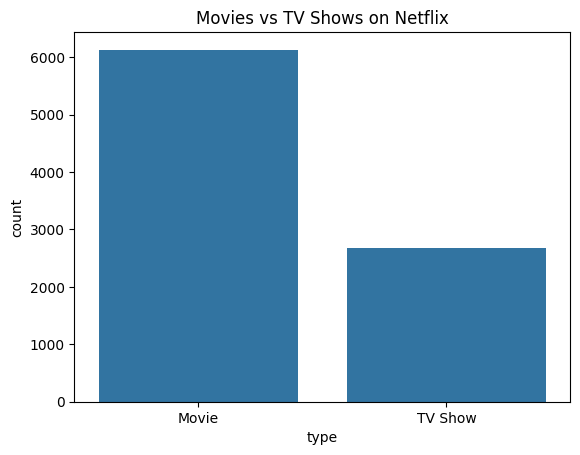

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(x='type', data=df)

plt.title('Movies vs TV Shows on Netflix')

plt.show()

Observation:
Netflix contains significantly more Movies than TV Shows.
This indicates that the platform focuses more on movie content.

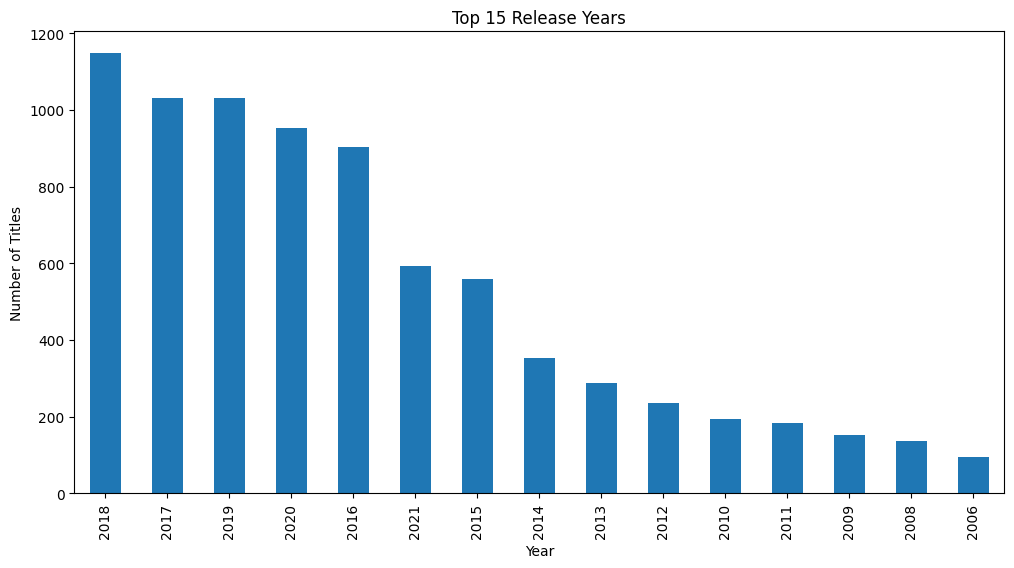

In [8]:
plt.figure(figsize=(12,6))

df['release_year'].value_counts().head(15).plot(kind='bar')

plt.title('Top 15 Release Years')

plt.xlabel('Year')

plt.ylabel('Number of Titles')

plt.show()

Observation:
Netflix content increased rapidly after 2015.
This suggests major expansion in content production during recent years.

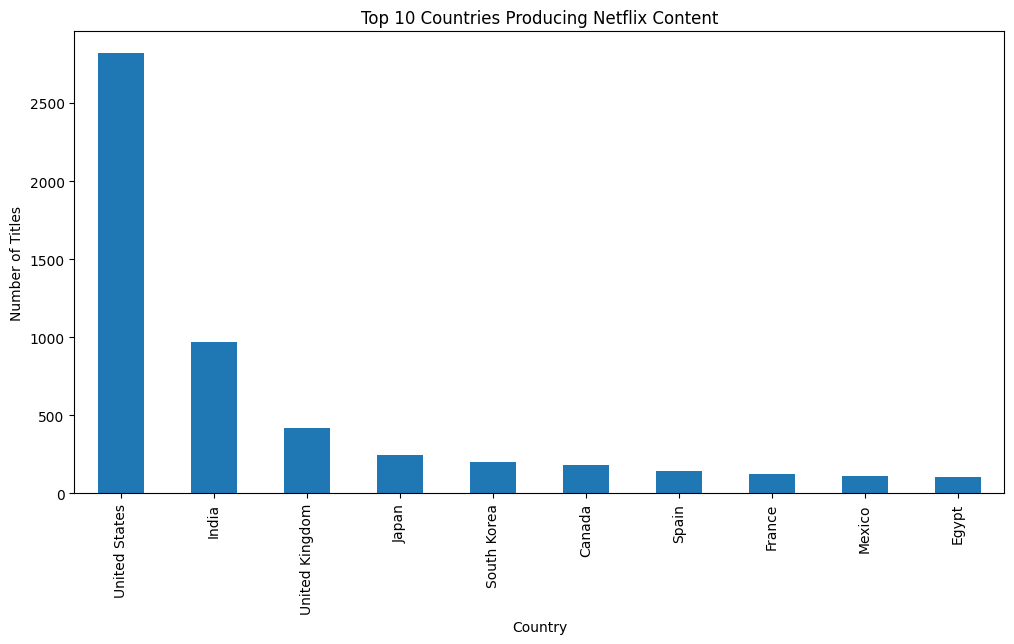

In [10]:
plt.figure(figsize=(12,6))

df['country'].value_counts().head(10).plot(kind='bar')

plt.title('Top 10 Countries Producing Netflix Content')

plt.xlabel('Country')

plt.ylabel('Number of Titles')

plt.show()

Observation:
The United States produces the highest amount of Netflix content.
India and the United Kingdom are also major contributors.

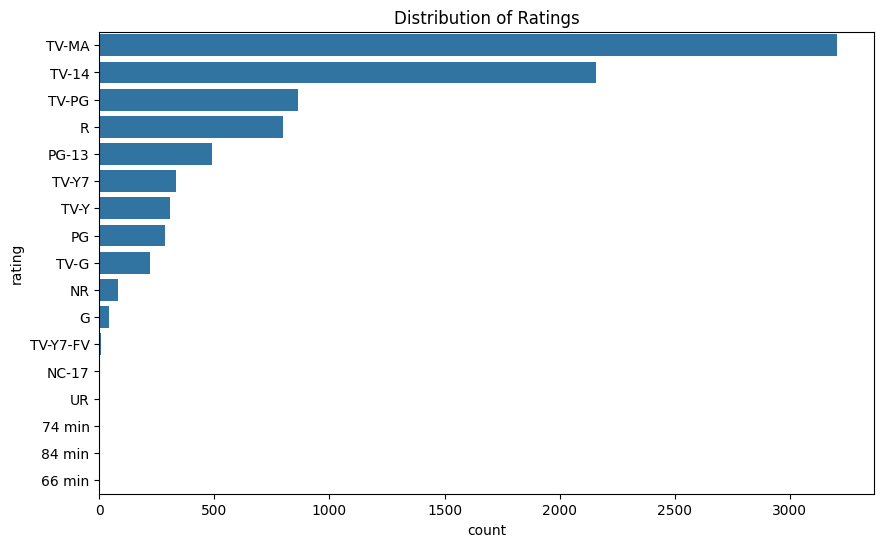

In [11]:
plt.figure(figsize=(10,6))

sns.countplot(y='rating',
data=df,
order=df['rating'].value_counts().index)

plt.title('Distribution of Ratings')

plt.show()

Observation:
TV-MA and TV-14 are the most common content ratings on Netflix.
This indicates that Netflix mainly targets mature and teenage audiences.

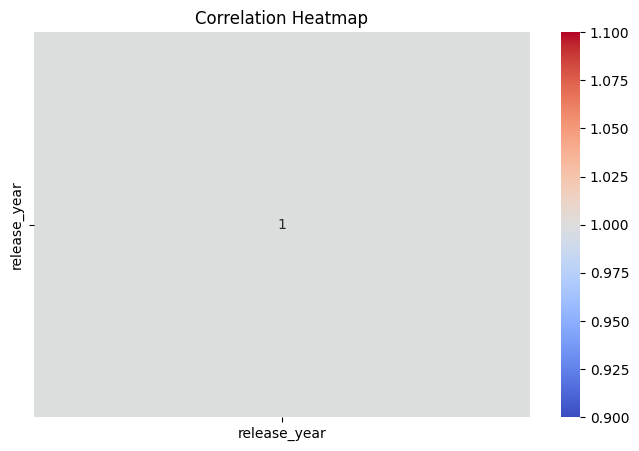

In [12]:
numeric_df = df.select_dtypes(include=['int64', 'float64'])

corr = numeric_df.corr()

plt.figure(figsize=(8,5))

sns.heatmap(corr,
annot=True,
cmap='coolwarm')

plt.title('Correlation Heatmap')

plt.show()

Observation:
The correlation heatmap shows relationships between numerical variables.
No strong negative correlations are observed in the dataset.

# Conclusion

This Exploratory Data Analysis project analyzed the Netflix dataset to identify trends and patterns.

Key findings include:
- Netflix contains more Movies than TV Shows.
- Content production increased rapidly after 2015.
- The United States contributes the highest number of titles.
- TV-MA is the most frequent rating category.

The project improved understanding of data cleaning, visualization, statistical analysis, and insight generation using Python libraries such as Pandas, Matplotlib, and Seaborn.